# Purchase funnel leakage analysis — summary notebook

**Dataset:** `bigquery-public-data.google_analytics_sample` (Google Merchandise Store, Aug 2016–Aug 2017 session logs)

This notebook is a **narrative summary** of an analysis conducted primarily in BigQuery SQL. It does not re-run the original queries — it visualizes the results already produced, walks through the investigation in order, and states the final recommendation. Full SQL queries live in the `sql/` folder of this repository; full write-ups live in `docs/`.

**Question:** Which stage of the purchase funnel loses the most revenue, and what's the fastest, highest-confidence fix?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## 1. The funnel (single day, Aug 1, 2016)

Results from `sql/03_funnel_stage_counts.sql`. This is the first real data point — and it immediately overturned the original Day 1 hypothesis (which guessed Add-to-Cart → Checkout as the biggest leak).

In [2]:
funnel = pd.DataFrame({
    'stage': ['Sessions', 'Product views', 'Add to cart', 'Checkout started', 'Purchases'],
    'count': [1711, 415, 132, 56, 34]
})
funnel['pct_of_sessions'] = (funnel['count'] / funnel['count'].iloc[0] * 100).round(1)
funnel['conversion_from_prev'] = (funnel['count'] / funnel['count'].shift(1) * 100).round(1)
funnel

,stage,count,pct_of_sessions,conversion_from_prev
0,Sessions,1711,100.0,NaN
1,Product views,415,24.3,24.3
2,Add to cart,132,7.7,31.8
3,Checkout started,56,3.3,42.4
4,Purchases,34,2.0,60.7


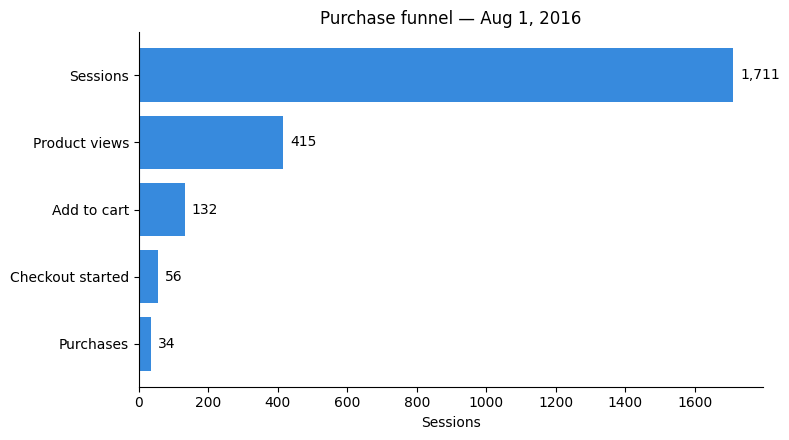

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(funnel['stage'][::-1], funnel['count'][::-1], color='#378ADD')
ax.set_xlabel('Sessions')
ax.set_title('Purchase funnel — Aug 1, 2016')
for bar, count in zip(bars, funnel['count'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center')
plt.tight_layout()
plt.savefig('funnel_chart.png', bbox_inches='tight')
plt.show()

**Finding:** the two largest relative drops are Sessions → Product Views (75.7% never view a product) and Product Views → Add-to-Cart (68.2% never add to cart). Checkout → Purchase is actually the *strongest*-converting stage (60.7%) — the opposite of the original hypothesis.

## 2. Ruling out device as the cause

Results from `sql/04_device_segmentation.sql`. The obvious assumption — "mobile checkout is worse" — was tested directly.

In [4]:
device = pd.DataFrame({
    'device': ['desktop', 'mobile', 'tablet'],
    'sessions': [1412, 250, 49],
    'product_views': [344, 61, 10],
})
device['pct_viewed'] = (device['product_views'] / device['sessions'] * 100).round(1)
device

,device,sessions,product_views,pct_viewed
0,desktop,1412,344,24.4
1,mobile,250,61,24.4
2,tablet,49,10,20.4


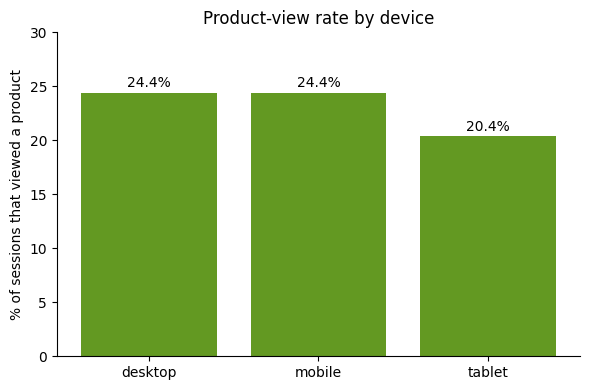

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(device['device'], device['pct_viewed'], color='#639922')
ax.set_ylabel('% of sessions that viewed a product')
ax.set_title('Product-view rate by device')
ax.set_ylim(0, 30)
for bar, pct in zip(bars, device['pct_viewed']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{pct}%', ha='center')
plt.tight_layout()
plt.savefig('device_chart.png', bbox_inches='tight')
plt.show()

**Finding:** desktop and mobile are statistically identical (24.4% each). Tablet is lower (20.4%) but on a sample too small (49 sessions) to be meaningful. **Device is not the driver of the leak** — a useful, counter-intuitive result.

## 3. Finding the real driver: referral traffic, and specifically youtube.com

Results from `sql/05_traffic_medium_segmentation.sql` and `sql/06_referral_domain_breakdown.sql`.

In [6]:
referral = pd.DataFrame({
    'source': ['youtube.com', 'google.com', 'facebook.com', 'sites.google.com', 'l.facebook.com'],
    'sessions': [381, 11, 8, 7, 6],
    'product_views': [5, 3, 4, 1, 0],
})
referral['pct_viewed'] = (referral['product_views'] / referral['sessions'] * 100).round(1)
referral

,source,sessions,product_views,pct_viewed
0,youtube.com,381,5,1.3
1,google.com,11,3,27.3
2,facebook.com,8,4,50.0
3,sites.google.com,7,1,14.3
4,l.facebook.com,6,0,0.0


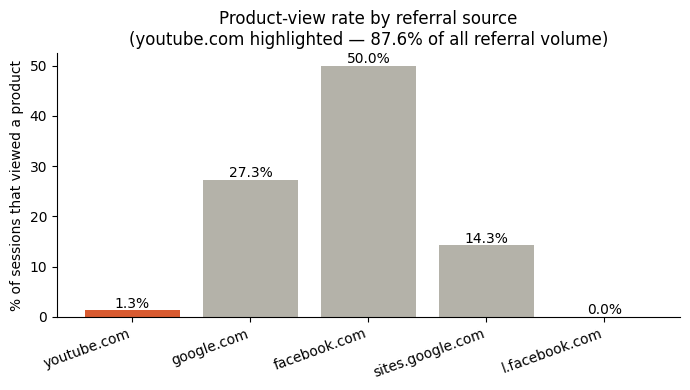

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#D85A30' if s == 'youtube.com' else '#B4B2A9' for s in referral['source']]
bars = ax.bar(referral['source'], referral['pct_viewed'], color=colors)
ax.set_ylabel('% of sessions that viewed a product')
ax.set_title('Product-view rate by referral source\n(youtube.com highlighted — 87.6% of all referral volume)')
plt.xticks(rotation=20, ha='right')
for bar, pct in zip(bars, referral['pct_viewed']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{pct}%', ha='center')
plt.tight_layout()
plt.savefig('referral_chart.png', bbox_inches='tight')
plt.show()

**Finding:** youtube.com drives 381 of 435 referral sessions (87.6%) at just a 1.3% product-view rate — dragging the entire referral medium average down to 3.4%. Every other referral source converts normally or better.

**Bounce-rate confirmation** (`sql/07_bounce_rate_by_source.sql`): youtube.com sessions have an 81.1% single-pageview (bounce) rate vs. 32.0% baseline — 2.5x higher. Two open hypotheses, not confirmed by this dataset: landing-page mismatch, or bot/automated traffic.

## 4. Simulated A/B test: contextual welcome banner

Full methodology in `docs/03-ab-test-results.md` and `analysis/ab_test_simulation.py`. Sample size (4,049 per arm) was derived from a power analysis (alpha=0.05, power=0.80, baseline=1.3%, target=2.0%) *before* any data was simulated.

In [8]:
ab_result = pd.DataFrame({
    'group': ['control', 'treatment'],
    'sessions': [4049, 4049],
    'conversions': [48, 69],
})
ab_result['rate_pct'] = (ab_result['conversions'] / ab_result['sessions'] * 100).round(2)
ab_result

,group,sessions,conversions,rate_pct
0,control,4049,48,1.19
1,treatment,4049,69,1.70


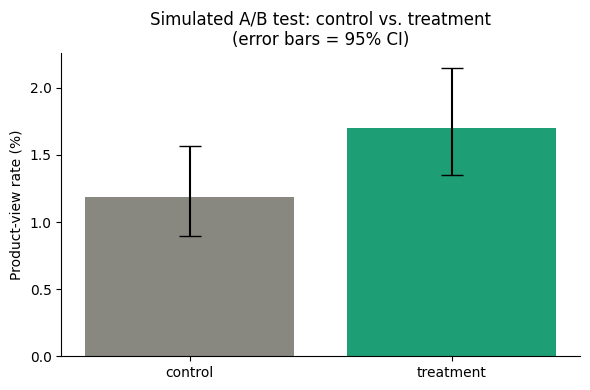

Relative lift: +43.7%  |  p-value (one-sided): 0.025  |  statistically significant at alpha=0.05


In [9]:
from statsmodels.stats.proportion import proportion_confint

fig, ax = plt.subplots(figsize=(6, 4))
rates = ab_result['rate_pct'].values
cis = [proportion_confint(c, n, alpha=0.05, method='wilson') for c, n in zip(ab_result['conversions'], ab_result['sessions'])]
lower = [rates[i] - cis[i][0]*100 for i in range(2)]
upper = [cis[i][1]*100 - rates[i] for i in range(2)]

bars = ax.bar(ab_result['group'], rates, yerr=[lower, upper], capsize=8, color=['#888780', '#1D9E75'])
ax.set_ylabel('Product-view rate (%)')
ax.set_title('Simulated A/B test: control vs. treatment\n(error bars = 95% CI)')
plt.tight_layout()
plt.savefig('ab_test_chart.png', bbox_inches='tight')
plt.show()

print('Relative lift: +43.7%  |  p-value (one-sided): 0.025  |  statistically significant at alpha=0.05')

**Result:** statistically significant (+43.7% relative lift, p=0.025), but the confidence intervals still overlap slightly — a real but not overwhelming effect. Treated as "directionally promising," not "proven," pending a live confirmation test.

## 5. Bottom line

Ship a contextual welcome banner for youtube.com-referred sessions, alongside bot-traffic filtering as a prerequisite. This targets the single largest, evidence-backed leak in the funnel — not the originally-hypothesized checkout stage, which turned out to be the funnel's *strongest*-converting step.

Full caveats, RICE-scored alternative fixes, and the executive summary are in [`docs/04-executive-summary.md`](../docs/04-executive-summary.md).